# Hotel Booking 
# EDA: What Drives Cancellation?

Business question: **what factors are associated with booking cancellation?**

This notebook is for the observational data, not an experiment.
Findings below describe **associations** (bookings with characteristic X
cancel more/less often), not proven causes.

## Setup

In [32]:
import sys

sys.path.append('../src')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from data_cleaning import clean_hotel_data
from eda_helpers import print_value_counts, plot_boxplot, plot_correlation_heatmap, plot_rate_by_category


pd.set_option('display.max_columns', 40)

## Data loading

In [26]:
df_raw = pd.read_csv('../data/raw/hotel_bookings.csv')
print(f"Raw: {df_raw.shape[0]:,} rows, {df_raw.shape[1]} columns")

Raw: 119,390 rows, 32 columns


## What drives cancellation?

In this section we will use the cleaned data then perform few eda to understand the relationship between the columns with the cancellation rate. 


In [9]:
df = clean_hotel_data(df_raw)
print(f"Clean: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"Overall cancellation rate: {df.cancelled.mean():.1%}")

Clean: 119,209 rows, 38 columns
Overall cancellation rate: 37.1%


We have **37.1% of bookings are canceled or
no-show.** Everything below cuts that rate by different factors.



### Cancellation by Lead time

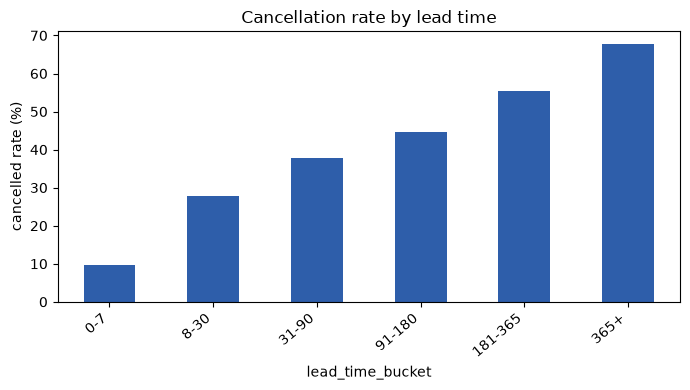

,n,positives,rate_pct
lead_time_bucket,,,
0-7,19635,1885,9.6
8-30,18945,5283,27.9
31-90,29529,11141,37.7
91-180,26420,11819,44.7
181-365,21533,11942,55.5
365+,3147,2129,67.7


In [11]:
bins = [-1, 7, 30, 90, 180, 365, 10000]
labels = ['0-7', '8-30', '31-90', '91-180', '181-365', '365+']
df['lead_time_bucket'] = pd.cut(df['lead_time'], bins=bins, labels=labels)

ax, table = plot_rate_by_category(df, 'lead_time_bucket', target_col='cancelled', min_n=1,
                                    title='Cancellation rate by lead time', sort_by_rate=False)
plt.show()
table.reindex(labels)

Clean, close-to-monotonic relationship: cancellation rate climbs from
10% (booked within a week) to 56% (booked over a year out). This is a strong correlation with cancellation. (checked below) and
the most defensible candidate for business action. Worth checking later
whether this holds within each channel, or is just proxying for something
else like distribution channel.

### By Guest History

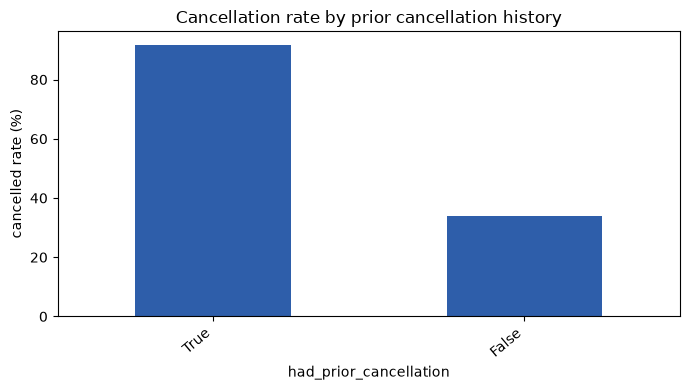

,n,positives,rate_pct
had_prior_cancellation,,,
True,6479,5940,91.7
False,112730,38259,33.9


In [ ]:
df['had_prior_cancellation'] = df['previous_cancellations'] > 0
ax, table = plot_rate_by_category(df, 'had_prior_cancellation', target_col='cancelled', min_n=1,
                                    title='Cancellation rate by prior cancellation history')
plt.show()
table

### By Special Requests

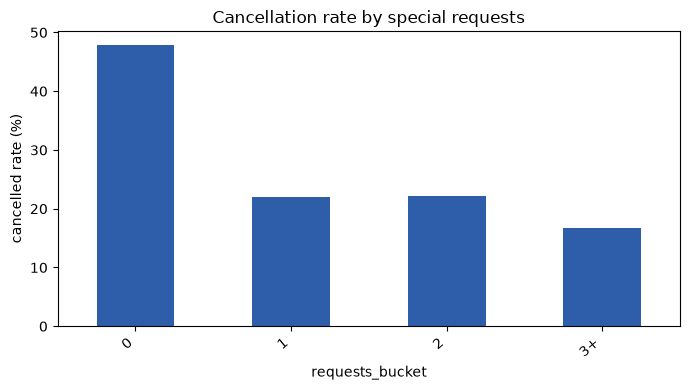

,n,positives,rate_pct
requests_bucket,,,
0,70200,33534,47.8
1,33183,7316,22.0
2,12952,2866,22.1
3+,2874,483,16.8


In [28]:

df['requests_bucket'] = df['total_of_special_requests'].clip(upper=3).astype(str)
df.loc[df['total_of_special_requests'] >= 3, 'requests_bucket'] = '3+'
ax, table = plot_rate_by_category(df, 'requests_bucket', target_col='cancelled', min_n=1,
                                    title='Cancellation rate by special requests', sort_by_rate=False)
plt.show()
table.reindex(['0', '1', '2', '3+'])

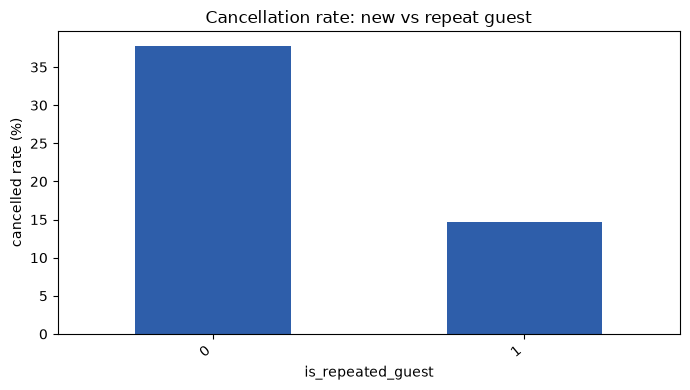

,n,positives,rate_pct
is_repeated_guest,,,
0,115455,43649,37.8
1,3754,550,14.7


In [29]:

ax, table = plot_rate_by_category(df, 'is_repeated_guest', target_col='cancelled', min_n=1,
                                    title='Cancellation rate: new vs repeat guest')
plt.show()
table

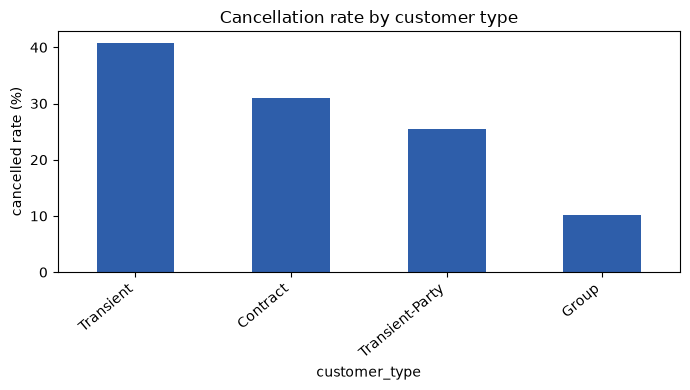

,n,positives,rate_pct
customer_type,,,
Transient,89476,36494,40.8
Contract,4072,1262,31.0
Transient-Party,25087,6385,25.5
Group,574,58,10.1


In [31]:
ax, table = plot_rate_by_category(df, 'customer_type', target_col='cancelled', min_n=100,
                                    title='Cancellation rate by customer type')
plt.show()
table

### By Market Segment

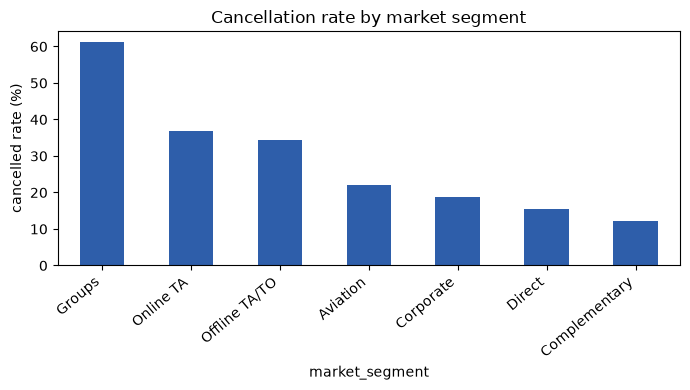

,n,positives,rate_pct
market_segment,,,
Groups,19790,12094,61.1
Online TA,56408,20735,36.8
Offline TA/TO,24182,8302,34.3
Aviation,235,52,22.1
Corporate,5282,991,18.8
Direct,12582,1934,15.4
Complementary,728,89,12.2


In [ ]:
ax, table = plot_rate_by_category(df, 'market_segment', target_col='cancelled', min_n=100,
                                    title='Cancellation rate by market segment')
plt.show()
table

### By Distribution Channel

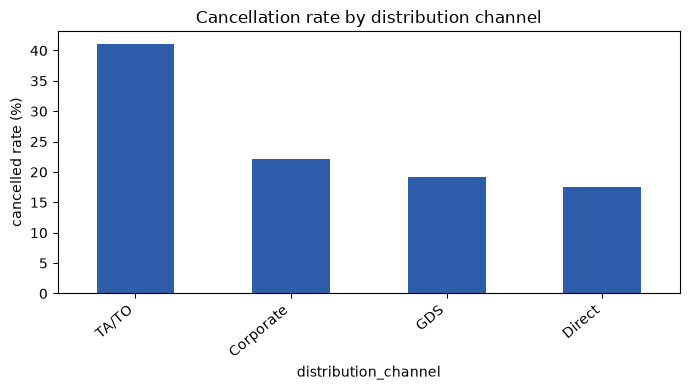

,n,positives,rate_pct
distribution_channel,,,
TA/TO,97750,40136,41.1
Corporate,6651,1467,22.1
GDS,193,37,19.2
Direct,14610,2555,17.5


In [13]:
ax, table = plot_rate_by_category(df, 'distribution_channel', target_col='cancelled', min_n=50,
                                    title='Cancellation rate by distribution channel')
plt.show()
table

Online TA / TA-TO stands out on both cuts — it's both the single
biggest segment/channel and the highest-cancellation one, so it accounts
for a disproportionate share of total cancellations. Direct and Corporate
cancel far less.

### Deposit type

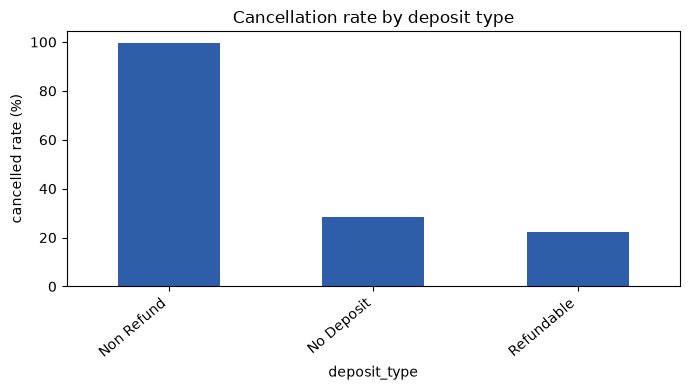

,n,positives,rate_pct
deposit_type,,,
Non Refund,14587,14494,99.4
No Deposit,104460,29669,28.4
Refundable,162,36,22.2


In [14]:
ax, table = plot_rate_by_category(df, 'deposit_type', target_col='cancelled', min_n=1,
                                    title='Cancellation rate by deposit type')
plt.show()
table

Non-refundable deposits cancel at ~99%?? That's backwards — a
non-refundable deposit should *discourage* cancellation, not predict it
almost certainly. Small group (~1,000 bookings) but the direction is too
extreme and too counter-intuitive to treat as a real behavioral driver.
Flagging as a likely data/process anomaly (e.g. wholesale bookings marked
"canceled" when unsold) that needs validation with the source system, not
presenting it as a usable finding.

### Correlation view (numeric, booking-time variables only)

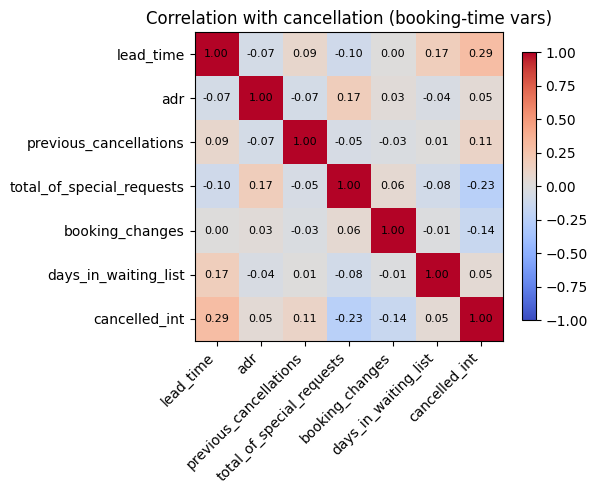

In [22]:
df['cancelled_int'] = df['cancelled'].astype(int)
numeric_check_cols = ['lead_time', 'adr', 'previous_cancellations', 'total_of_special_requests',
                       'booking_changes', 'days_in_waiting_list', 'cancelled_int']
plot_correlation_heatmap(df, numeric_check_cols, title='Correlation with cancellation (booking-time vars)')
plt.show()

Lead time is the strongest positive correlation, consistent with the
bucketed view above. Howerver, total of special requests is the oposite (more requests leads to low cancellation rate)

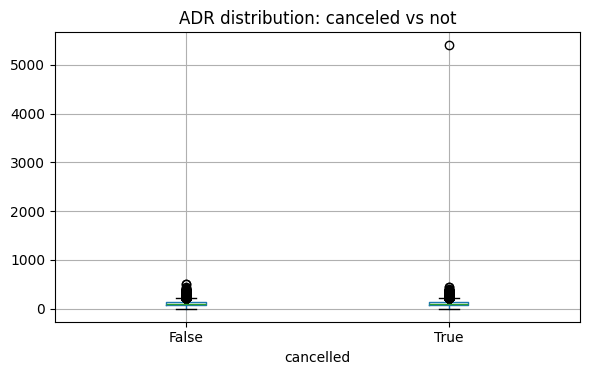

In [23]:
plot_boxplot(df, 'adr', by='cancelled', title='ADR distribution: canceled vs not')
plt.show()

ADR distributions look broadly similar between
canceled/not-canceled not a strong signal on its own.

## Summary what actually drives cancellation

Ranked by how much I'd trust each one:

1. **Lead time** — cleanest, most defensible signal. Holds up even after
   checking it isn't just proxying for distribution channel (stronger
   within TA/TO, weaker within Direct/Corporate, but present in all).
2. **Distribution channel / market segment** — Online TA / TA-TO cancels
   far more than Direct or Corporate, and it's also the largest channel by
   volume, so it drives a disproportionate share of total cancellations.
3. **Guest history and engagement** — prior cancellations, special
   requests, and repeat-guest status all point the same direction
   (more "invested" guests cancel less). Consistent across three signals,
   still just association.
4. **Deposit type** — strongest raw association in the data (94-99%
   cancellation on non-refundable deposits) but flagged, not trusted —
   direction is implausible for a real behavioral effect and needs
   validation against the source system before it's used for anything.
5. **Room type changed** — excluded. Leakage, not a driver: only known
   after the guest has already shown up.

Next step: `scripts/03_analysis_cancellations.py` turns this into the
final charts and write-up for `analysis/cancellation_drivers_findings.md`.